<a href="https://colab.research.google.com/github/samarreguigui/summarization/blob/main/COMPARE_finesure_vs_llmjudge_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FineSurE vs a plain LLM-as-a-judge (RQ1 summaries)

**FineSurE** (already computed in RQ1): decomposes each summary into sentences, classifies each into
nine error categories, and counts keyfact coverage — three scores computed as ratios.

**LLM-as-a-judge** (here, same GPT-4o as FineSurE): reads the whole article + the whole summary in ONE prompt and
returns the three scores directly, no sentence pipeline and no keyfact list.

We reuse the saved FineSurE scores (`scores_master.csv`) — FineSurE is **not** re-run — and only make
one GPT-4o judge call per summary. Then we compare the two judges per summary on the three dimensions.

Run top to bottom.

## 1. Setup

In [6]:
import importlib, subprocess, sys
for pip_name, imp in {'pymupdf':'fitz','pandas':'pandas','openai':'openai','nltk':'nltk',
                      'matplotlib':'matplotlib','scipy':'scipy','tiktoken':'tiktoken'}.items():
    try: importlib.import_module(imp)
    except ImportError: subprocess.check_call(['pip','-q','install','--upgrade',pip_name])
import nltk; nltk.download('punkt', quiet=True); nltk.download('punkt_tab', quiet=True)
from google.colab import drive
drive.mount('/content/drive')
print('setup done')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
setup done


## 2. Config

In [ ]:
from pathlib import Path

PROJECT     = Path('/content/drive/MyDrive/summarization')
PAPER_DIR   = PROJECT / 'data' / 'paper'
SUMMARY_DIR = PROJECT / 'data' / 'different summaries size'
KEY_FILE    = PROJECT / 'api_key.txt'                    # your key location (change if it moved)

RQ1_RUN      = PROJECT / 'verbosity_bias_run'            # already-computed FineSurE run
RQ1_SCORES   = RQ1_RUN / 'results' / 'scores_master.csv'
RQ1_ARTICLES = RQ1_RUN / 'articles'                     # cleaned article text, one .txt per paper

OUT   = PROJECT / 'normal_judge_run'                     # everything new goes here
CACHE = OUT / 'cache'; FIG = OUT / 'figures'
for d in [OUT, CACHE, FIG]: d.mkdir(parents=True, exist_ok=True)

# SAME base model FineSurE used (RQ1), so the comparison isolates the METHOD, not the model.
MODEL_JUDGE    = 'openai/gpt-4o-2024-05-13'
OPENROUTER_URL = 'https://openrouter.ai/api/v1'
TEMPERATURE    = 0.0
print('FineSurE scores :', RQ1_SCORES)
print('LLM judge       :', MODEL_JUDGE, '(same base model as FineSurE)')

## 3. Load saved FineSurE scores + article/summary text (no FineSurE re-run)

In [8]:
import pandas as pd, re, fitz

fs = pd.read_csv(RQ1_SCORES); fs.columns = [c.strip() for c in fs.columns]
print('FineSurE summaries:', len(fs), '| columns:', list(fs.columns))

def clean_summary(raw): return re.sub(r'\s+', ' ', raw).strip()
def read_pdf(p):
    d = fitz.open(p); t = '\n'.join(pg.get_text() for pg in d); d.close(); return t
def clean_article(raw):
    raw = re.split(r'\n\s*(References|REFERENCES|Bibliography)\b', raw, maxsplit=1)[0]
    return re.sub(r'\n{3,}','\n\n', re.sub(r'[ \t]+',' ', raw)).strip()

def article_text(pid):
    f = RQ1_ARTICLES / f'{pid}.txt'
    if f.exists(): return f.read_text()
    m = sorted(PAPER_DIR.glob(f'{pid}_*.pdf')); assert m, f'no article for {pid}'
    return clean_article(read_pdf(m[0]))

def summary_text(label):
    m = sorted(SUMMARY_DIR.glob(f'{label}.pdf')); assert m, f'no summary pdf for {label}'
    return clean_summary(read_pdf(m[0]))

fs.head()

FineSurE summaries: 20 | columns: ['paper_id', 'summary_label', 'size', 'realised_tokens', 'n_sentences', 'faithfulness', 'completeness', 'conciseness', 'n_keyfacts_total', 'n_keyfacts_covered']


,paper_id,summary_label,size,realised_tokens,n_sentences,faithfulness,completeness,conciseness,n_keyfacts_total,n_keyfacts_covered
0,1,01_sum1_short,short,190,8,1.000000,0.3125,0.375000,16,5
1,1,01_sum1_medium,medium,435,18,0.857143,0.6250,0.444444,16,10
2,1,01_sum_long_gen_hum,long,1485,44,0.783784,0.8125,0.250000,16,13
3,2,02_sum1_short,short,306,13,1.000000,0.6875,0.846154,16,11
4,2,02_sum1_medium_gen_hum,medium,662,23,1.000000,0.6875,0.391304,16,11


## 4. The LLM-as-a-judge (same GPT-4o as FineSurE), cached

One prompt, all three scores + the sentences it thinks are unsupported. The prompt defines each
dimension as a *fraction* so the 0-1 numbers mean the same thing FineSurE's ratios do.

In [9]:
import openai, hashlib, json, time, ast
client = openai.OpenAI(api_key=KEY_FILE.read_text().strip(), base_url=OPENROUTER_URL)

def get_response(prompt, model, tries=3):
    key = hashlib.sha256(f'{model}|{TEMPERATURE}|{prompt}'.encode()).hexdigest()[:24]
    cf = CACHE / f'{key}.json'
    if cf.exists(): return json.loads(cf.read_text())['response']
    last = None
    for a in range(tries):
        try:
            r = client.chat.completions.create(model=model, temperature=TEMPERATURE,
                                               messages=[{'role':'user','content':prompt}])
            txt = r.choices[0].message.content
            cf.write_text(json.dumps({'prompt':prompt,'response':txt})); return txt
        except Exception as e:
            last = e; time.sleep(2**a)
    raise RuntimeError(f'API failed: {last}')

JUDGE_PROMPT = '''You are an expert evaluator of scientific-paper summaries. You will be given a
SOURCE ARTICLE and a SUMMARY of it. Judge the SUMMARY on three independent dimensions, using ONLY
the article as ground truth (do not use outside knowledge).

Score each dimension from 0.0 to 1.0:

1. FAITHFULNESS - the fraction of the summary's factual claims that are directly supported by the
   article. A claim is unsupported if it is absent from, or contradicts, the article. 1.0 = every
   claim supported; the score falls as more claims are unsupported.

2. COMPLETENESS - how much of the article's most important information the summary captures.
   1.0 = all key points present; the score falls as important points are missing.

3. CONCISENESS - the fraction of the summary that conveys important, on-topic information rather than
   redundant, trivial, or background/filler content. 1.0 = every sentence carries a key point.
   Judge information density, NOT writing style or length by itself.

Instructions:
- Judge the three dimensions independently.
- For faithfulness, list every summary sentence that is not supported by the article, each with a
  one-line reason.
- Base every judgment only on the article.

Return ONLY valid JSON in exactly this shape:
{{"faithfulness": <float 0-1>, "completeness": <float 0-1>, "conciseness": <float 0-1>,
  "unsupported_sentences": [{{"sentence": "<exact summary sentence>", "reason": "<why unsupported>"}}],
  "justification": "<2-3 sentences>"}}

SOURCE ARTICLE:
{article}

SUMMARY:
{summary}'''

def parse_json(raw):
    txt = (raw or '').replace('```json','').replace('```','')
    s, e = txt.find('{'), txt.rfind('}')
    if s==-1 or e<=s: return None
    for loader in (ast.literal_eval, json.loads):
        try: return loader(txt[s:e+1])
        except Exception: pass
    return None
print('judge ready')

judge ready


## 5. Run the judge on all 20 summaries

Faithfulness is kept two ways: the judge's holistic 0-1 (`faith_holistic`), and the FineSurE-style
ratio `1 - flagged/n_sentences` using FineSurE's saved `n_sentences` (`faith_ratio`, the value-for-value
comparable one).

In [ ]:
from tqdm.auto import tqdm
rows = []
for _, r in tqdm(list(fs.iterrows()), total=len(fs)):
    pid, label = str(r['paper_id']).zfill(2), r['summary_label']
    n_sent = int(r['n_sentences'])
    raw = get_response(JUDGE_PROMPT.format(article=article_text(pid), summary=summary_text(label)), MODEL_JUDGE)
    d = parse_json(raw) or {}
    errs = d.get('unsupported_sentences') or []
    n_err = len([e for e in errs if isinstance(e, dict) and str(e.get('sentence','')).strip()])
    n_err = min(n_err, n_sent)                                   # clamp: can't exceed sentence count
    rows.append({
        'summary_label': label,
        'faith_holistic': d.get('faithfulness'),
        'faith_ratio': round(1 - n_err/n_sent, 3) if n_sent else None,
        'comp_normal': d.get('completeness'),
        'conc_normal': d.get('conciseness'),
        'n_err_found': n_err,
        'errors_found': ' | '.join(str(e.get('sentence',''))[:80] for e in errs if isinstance(e, dict)),
        'justification': d.get('justification',''),
    })
normal = pd.DataFrame(rows)
normal.to_csv(OUT/'normal_scores.csv', index=False)
print('judge done:', len(normal), '| parsed:', normal['comp_normal'].notna().sum())
normal.head()

## 6. Merge + per-summary agreement

In [11]:
import numpy as np
from scipy.stats import pearsonr, spearmanr

cmp = fs.merge(normal, on='summary_label', how='left')
cmp.to_csv(OUT/'comparison.csv', index=False)

# (finesure_col, normal_col, name, value_comparable?)
DIMS = [('faithfulness','faith_ratio','faithfulness', True),
        ('completeness','comp_normal','completeness', False),
        ('conciseness','conc_normal','conciseness',  False)]

print('FineSurE vs LLM judge, per-summary agreement (n=%d)\n' % len(cmp))
for fcol, ncol, name, val in DIMS:
    a = pd.to_numeric(cmp[fcol], errors='coerce'); b = pd.to_numeric(cmp[ncol], errors='coerce')
    ok = a.notna() & b.notna()
    pear = pearsonr(a[ok], b[ok])[0]; spear = spearmanr(a[ok], b[ok])[0]
    tag = 'value-comparable' if val else 'RANK-comparable only (different construct)'
    print(f'{name:13s}: Pearson {pear:+.2f} | Spearman {spear:+.2f} | '
          f'mean|gap| {(a[ok]-b[ok]).abs().mean():.3f}   [{tag}]')

show = cmp[['summary_label','size','faithfulness','faith_ratio','faith_holistic',
            'completeness','comp_normal','conciseness','conc_normal']]
with pd.option_context('display.max_rows',None,'display.width',180):
    print('\n', show.round(3).to_string(index=False))

FineSurE vs LLM judge, per-summary agreement (n=20)

faithfulness : Pearson +0.66 | Spearman +0.15 | mean|gap| 0.121   [value-comparable]
completeness : Pearson +0.81 | Spearman +0.80 | mean|gap| 0.207   [RANK-comparable only (different construct)]
conciseness  : Pearson -0.24 | Spearman +0.10 | mean|gap| 0.431   [RANK-comparable only (different construct)]

           summary_label     size  faithfulness  faith_ratio  faith_holistic  completeness  comp_normal  conciseness  conc_normal
          01_sum1_short    short         1.000        0.750             0.8         0.312         0.70        0.375         0.90
         01_sum1_medium   medium         0.857        0.944             0.9         0.625         0.80        0.444         0.90
    01_sum_long_gen_hum     long         0.784        0.955             0.9         0.812         0.95        0.250         0.85
          02_sum1_short    short         1.000        0.846             0.8         0.688         0.90        0.846       

## 7. Agreement scatter (FineSurE x vs judge y)

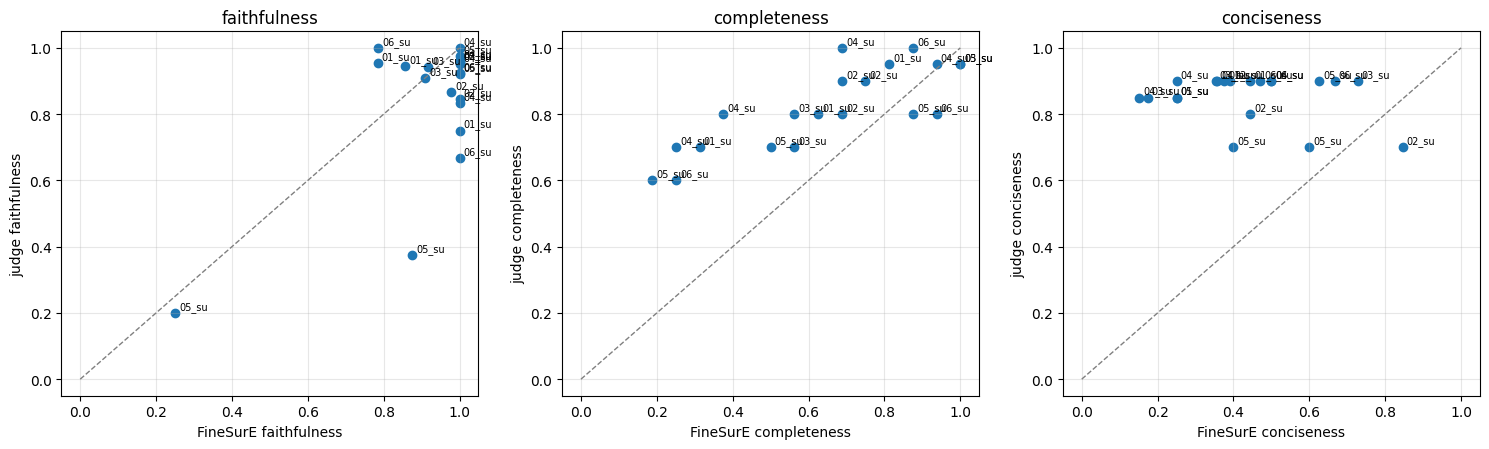

In [15]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
for ax,(fcol,ncol,name,val) in zip(axes, DIMS):
    a = pd.to_numeric(cmp[fcol], errors='coerce'); b = pd.to_numeric(cmp[ncol], errors='coerce')
    ax.plot([0,1],[0,1],'--',color='gray',lw=1)
    ax.scatter(a, b)
    for _,r in cmp.iterrows():
        ax.annotate(r['summary_label'][:5], (r[fcol], r[ncol]), fontsize=7,
                    xytext=(3,3), textcoords='offset points')
    ax.set_xlim(-.05,1.05); ax.set_ylim(-.05,1.05)
    ax.set_xlabel(f'FineSurE {name}'); ax.set_ylabel(f'judge {name}')
    ax.set_title(name ); ax.grid(alpha=.3)
plt.tight_layout(); fig.savefig(FIG/'agreement_scatter.png', dpi=120); plt.show()

## 8. Where they disagree most (faithfulness)

In [13]:
cmp['faith_gap'] = (pd.to_numeric(cmp['faithfulness'],errors='coerce')
                    - pd.to_numeric(cmp['faith_ratio'],errors='coerce'))
big = cmp.reindex(cmp['faith_gap'].abs().sort_values(ascending=False).index)
print('summary            FineSurE  judge   gap   #err')
for _, r in big.head(8).iterrows():
    fr = r['faith_ratio']
    print(f"{r['summary_label']:18s} {r['faithfulness']:.2f}    "
          f"{fr if pd.notna(fr) else float('nan'):.2f}   {r['faith_gap']:+.2f}   {int(r['n_err_found'])}")
print('\nsentences the judge flagged as unsupported:')
for _, r in normal.iterrows():
    if r['n_err_found']: print(f"  {r['summary_label']}: {r['errors_found']}")

summary            FineSurE  judge   gap   #err
05_sum2_short      0.88    0.38   +0.50   5
06_sum_short       1.00    0.67   +0.33   2
01_sum1_short      1.00    0.75   +0.25   2
06_sum_medium_gen_human 0.79    1.00   -0.21   0
01_sum_long_gen_hum 0.78    0.95   -0.17   2
04_sum1_short      1.00    0.83   +0.17   1
02_sum1_short      1.00    0.85   +0.15   2
02_sum1_long_gen_hum 0.98    0.87   +0.11   6

sentences the judge flagged as unsupported:
  01_sum1_short: Correlation is ALWAYS higher on non-expert annotated data rather than expert ann | Importantly LLMs perform better on human generated text in general, leading to t
  01_sum1_medium: For example, GPT-4o ranks highest in many evaluation scenarios but performs wors
  01_sum_long_gen_hum: The authors — a large European consortium that includes two researchers from you | A particularly careful touch is the human upper bound: borrowing logic from neur
  02_sum1_short: The authors believe the community is focused on this 'race' for

## 9. Save

In [14]:
print('saved to', OUT)
for f in sorted(OUT.glob('*.csv')): print('  ', f.name)
for f in sorted(FIG.glob('*.png')): print('  figures/', f.name)

saved to /content/drive/MyDrive/summarization/normal_judge_run
   comparison.csv
   normal_scores.csv
  figures/ agreement_scatter.png
